In [1]:
import glob
import os
from PIL import Image
import nibabel 
import time
import sys
import shutil
from files2txt2files import read_list_from_file, save_list_to_file
import json
import numpy as np
import matplotlib.pyplot as plt


np_mr_arr = np.zeros((3001, 1))

np_ct_arr = np.zeros((4001, 1))

def nii_to_matrix_dict(folder, bad_data_file):

    bad_data = read_list_from_file(bad_data_file)

    partitions = [os.path.join(folder,dir) for dir in os.listdir(folder) if os.path.isdir(os.path.join(folder, dir))]
    for i, partition in enumerate(partitions):

        print(f"Starting work on partition \"{partition}\" ({i+1}/{len(partitions)})")

        #patient folders (some might not be..)
        patients = [os.path.join(partition,dir) for dir in os.listdir(partition) if (os.path.isdir(os.path.join(partition, dir)))]

        #enter each patient folder
        for patient in patients:

            patient_id = patient.split("/")[-1]
            print(f" Starting work on patient \"{patient_id}\"")
            os.chdir(patient) # I believe this is not needed

            #converts each scan of the patient individually
            for scan in glob.glob('*.nii.gz'):

                #we do not use the mask files so we delete then
                if scan == 'mask.nii.gz':
                    os.remove(scan)
                    continue

                #load the .nii.gz file
                nii = nibabel.load(scan)
                np_arr = np.asarray(nii.dataobj)

                for slice in range(np_arr.shape[2]):

                    if (f"{patient_id}-{slice:03}" in bad_data):
                        continue                    

                    # clean_arr.append(np_arr[:, :, slice])

                    #Minmaxnorm + scale as image
                    if (scan.split(".")[0] == "ct"):
                        for elm in np_arr[:, :, slice].flatten():
                            np_ct_arr[int(elm + 1000)] += 1
                        

                    if (scan.split(".")[0] == "mr"):    
                        for elm in np_arr[:, :, slice].flatten():
                            np_mr_arr[int(elm)] += 1

                del np_arr 
                del nii


In [2]:

def clean_folder(folder):
    print("Cleaning")
    dirs = [os.path.join(folder,dir) for dir in os.listdir(folder) if os.path.isdir(os.path.join(folder, dir))]

    for dir in dirs:
        shutil.rmtree(dir)

    zips = [os.path.join(folder,elm) for elm in os.listdir(folder) if elm.split(".")[-1] == "zip"]

    for z in zips:
        shutil.unpack_archive(z,folder)
    print("Done cleaning")

In [3]:
clean_folder("/Users/andershelbo/Desktop/MAKEDATA/Input_data")

start = time.time()
nii_to_matrix_dict("/Users/andershelbo/Desktop/MAKEDATA/Input_data", "/Users/andershelbo/Desktop/MAKEDATA/test_data.txt")
end = time.time()

Cleaning


FileNotFoundError: [Errno 2] No such file or directory: '/Users/andershelbo/Desktop/MAKEDATA/Input_data'

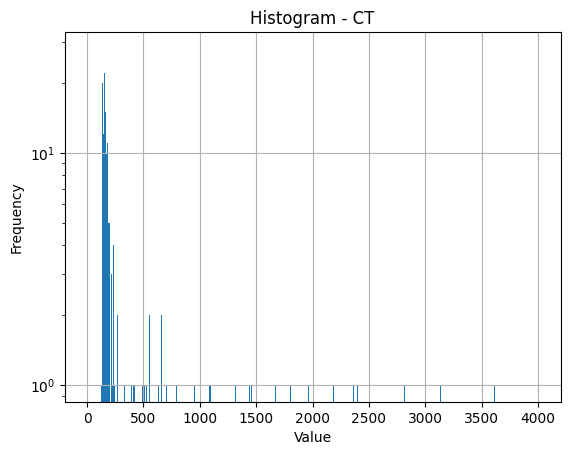

In [ ]:
def histogram_ct():
    global np_ct_arr
    plt.hist(np_ct_arr, bins=4001, range=(0, 4000))
    plt. title( 'Histogram - CT' )
    plt.xlabel ( 'Value')
    plt.ylabel('Frequency')
    plt.grid (True)
    #plt.ylim([0, 20])
    plt.yscale('log') 
    
    plt.show()

histogram_ct()

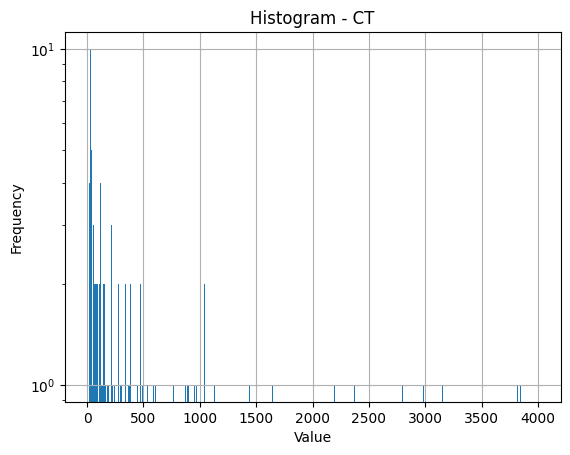

In [ ]:


def histogram_mr():
    global np_mr_arr
    plt.hist(np_mr_arr, bins=4001, range=(0, 4000))
    plt. title( 'Histogram - CT' )
    plt.xlabel ( 'Value')
    plt.ylabel('Frequency')
    plt.grid (True)
    #plt.ylim([0, 20])
    plt.yscale('log') 
    
    plt.show()

histogram_mr()

[-139.33876529]
[1160.16461595]


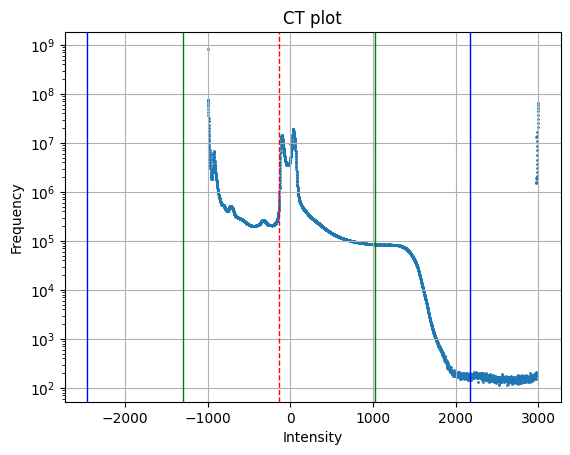

[1.00102234]
[344.81634477]


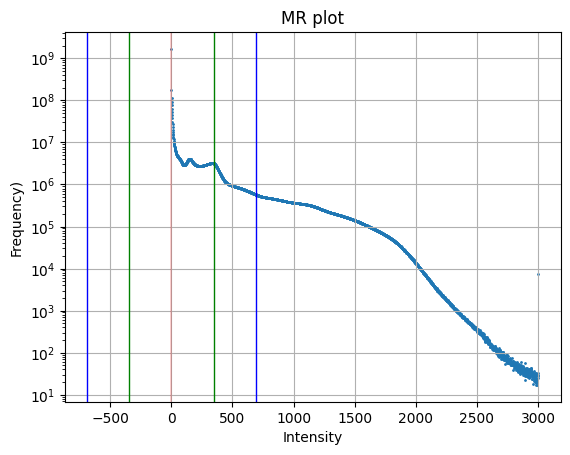

In [ ]:
import numpy as np

def plot_mr():
    global np_mr_arr

    # Compute mean and standard deviation
    mean = sum([i*elm for i, elm in enumerate(np_mr_arr)])/sum(np_mr_arr)
    plt.axvline(mean, color='r', linewidth=.25, label='Mean')
    print(mean)

    fx = sum([(((i)**2)*elm) for i, elm in enumerate(np_mr_arr)])
    N = sum(np_mr_arr)
    std = np.sqrt(fx/N)
    plt.axvline(mean+std, color='g', linewidth=1, label='1 std')
    plt.axvline(mean-std, color='g', linewidth=1, label='1 std')
    print(std)
    plt.axvline(mean+std*2, color='b', linewidth=1, label='2 std')
    plt.axvline(mean-std*2, color='b', linewidth=1, label='2 std')

    y_values = np.array(np_mr_arr)
    x_values = np.arange(len(y_values))
    plt.scatter(x_values, y_values, s=1)
    plt.xlabel('Intensity')
    plt.ylabel('Frequency)')
    plt.title('MR plot')
    plt.yscale('log')  # Set y-axis scale to logarithmic
    plt.grid(True)
    plt.show()

def plot_ct():
    global np_ct_arr

    # Compute mean and standard deviation
    mean = sum([(i-1000)*elm for i, elm in enumerate(np_ct_arr)])/sum(np_ct_arr)
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label='Mean')
    print(mean)

    fx = sum([(((x-1000)**2)*f) for x, f in enumerate(np_ct_arr)])
    N = sum(np_ct_arr)
    std = np.sqrt(fx/N-mean)
    plt.axvline(mean+std, color='g', linewidth=1, label='1 std')
    plt.axvline(mean-std, color='g', linewidth=1, label='1 std')
    print(std)
    plt.axvline(mean+std*2, color='b', linewidth=1, label='2 std')
    plt.axvline(mean-std*2, color='b', linewidth=1, label='2 std')


    y_values = np.array(np_ct_arr)
    # y_values = np.log(y_values)    
    x_values = np.arange(-1000, len(y_values) - 1000)
    plt.scatter(x_values, y_values, s=1)
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.title('CT plot')
    plt.yscale('log')  # Set y-axis scale to logarithmic
    plt.grid(True)
    plt.show()  

plot_ct()
plot_mr()